# Testing the draft segmented histogram (`team/new_graphics/segmented_hist.py`)

This notebook exercises `make_segmented_hist()`, the draft implementation of the
segmented histogram plot type — the histogram sibling of the segmented density plot
(team decision, 2026-07-15). It is **not** wired into `.plot()` yet — this is for
visually checking the draft before integration.

Same one-row-per-level layout as the segmented density plot, but each level of the
discrete variable shows a small **histogram** of the continuous values instead of a
smooth density curve — binned and blocky, so small-sample lumpiness stays visible
instead of being smoothed over. At integration it will be `type='segmented_hist'`.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for:**
- One small histogram per level, rising from that level's baseline, stacked along
  the discrete axis with a gentle overlap; lower rows sit in front
- All levels share one set of **bin edges** (bars line up in columns) and one
  **height scale** (a taller bar really is a taller density/count)
- Bars use the 1D histogram's styling — translucent fill (alpha 0.65), thin white
  edges — over an explicit baseline in the ridge color
- `normalize=True` (default): each level's bars show that level's density (area 1
  per level, shapes comparable); `normalize=False`: raw counts, so frequent levels
  get taller bars
- No arguments needed beyond the data and axes: `color` omitted → sky blue first,
  next Okabe-Ito hue on a second call (same cycle `get_next_color(ax)` reads)
- Levels too sparse for a histogram fall back to tick marks on their baseline,
  with a note
- Light reference grid on both axes; every level's baseline spans the shared bin
  range
- Axis labels "X"/"Y", title "Segmented Histogram"

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages), and `from segmented_hist import ...`
# find the draft module one folder up.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(Path.cwd().parent))

# The draft helper and its per-plot-type constants
from segmented_hist import (
    make_segmented_hist,
    SEGMENTED_HIST_ALPHA,
    SEGMENTED_HIST_DEFAULT_BINS,
    SEGMENTED_HIST_PEAK_SCALE,
)

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# The integrated symbulate/plot.py applies this same file at import, so
# the symbulate imports later in this notebook won't undo it.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(
    f"SEGMENTED_HIST_ALPHA = {SEGMENTED_HIST_ALPHA}, "
    f"SEGMENTED_HIST_DEFAULT_BINS = {SEGMENTED_HIST_DEFAULT_BINS}, "
    f"SEGMENTED_HIST_PEAK_SCALE = {SEGMENTED_HIST_PEAK_SCALE}"
)

SEGMENTED_HIST_ALPHA = 0.65, SEGMENTED_HIST_DEFAULT_BINS = 30, SEGMENTED_HIST_PEAK_SCALE = 1.6


## 1. The classic orientation — discrete y, continuous x

Five levels of a discrete variable on y, a continuous variable on x whose mean
shifts with the level. One row of upward bars per level. Because every level is
binned on the same shared edges (computed from the pooled values), the bars line up
in columns across rows; because they share one height scale, the tallest bar reaches
`SEGMENTED_HIST_PEAK_SCALE` (1.6) baseline spacings and every other bar keeps its
true relative height. Where rows overlap, the lower (nearer) row is drawn in front.

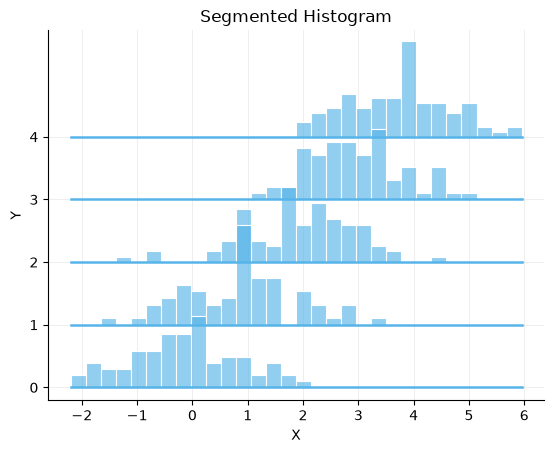

In [2]:
groups = rng.integers(0, 5, 400)            # discrete: 5 levels -> 5 rows
values = rng.normal(0, 1, 400) + groups     # continuous, shifted by level

ax = plt.gca()
make_segmented_hist(values, groups, ax)  # x continuous, y discrete; color automatic
plt.show()  # title, axis labels, and the sky-blue color are set automatically

## 2. Axes swapped — discrete x, continuous y

The same data passed in the other order. The bars now extend to the right of each
level's vertical baseline — matching how the segmented rug, segmented density, and
mixed tile plots flip when `x` is the discrete variable, so all views of one dataset
stay consistent.

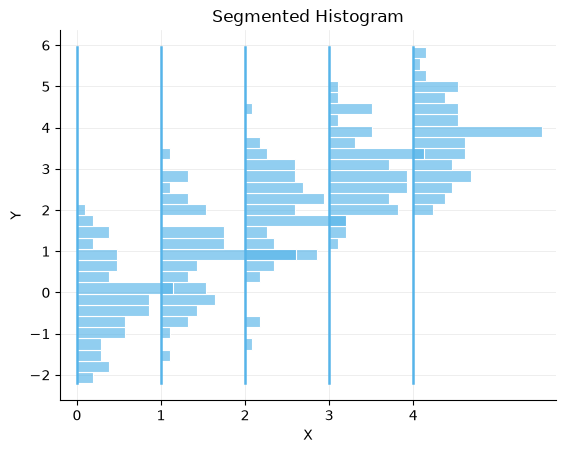

In [3]:
ax = plt.gca()
make_segmented_hist(groups, values, ax)  # x discrete, y continuous
plt.show()

## 3. Options: bins, normalize, alpha, explicit color

`bins=` sets the shared bin grid (int or explicit edges, default 30 — the package
histogram standard). `normalize=` switches between per-level density (True, default:
levels compared by shape) and raw counts (False: frequent levels get taller bars).
`alpha=` changes the bar fill. An explicit `color=` overrides the automatic cycle
(at integration, `.plot()` passes `get_next_color(ax)` in through this parameter).

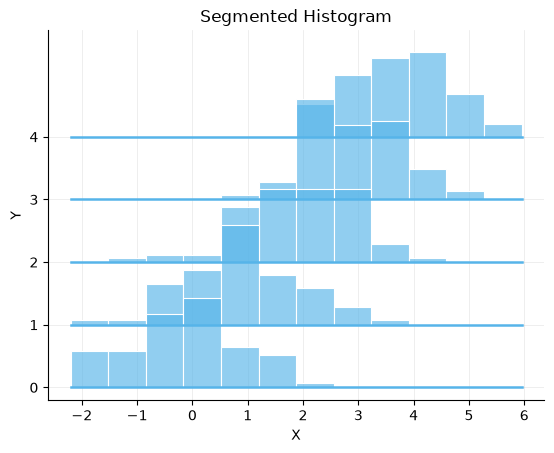

In [4]:
# Fewer, chunkier bins
ax = plt.gca()
make_segmented_hist(values, groups, ax, bins=12)
plt.show()

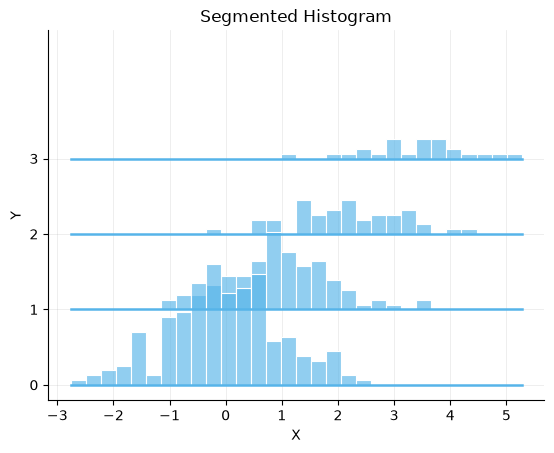

In [5]:
# normalize=False: raw counts. The group sizes here shrink 200 -> 100 -> 50 -> 25,
# so each row's bars get shorter as well as shifting -- the bar heights now mix the
# level's frequency with its shape. With the default normalize=True every level
# would have area 1 and be compared by shape alone.
sizes = [200, 100, 50, 25]
count_values = np.concatenate([rng.normal(i, 1, n) for i, n in enumerate(sizes)])
count_groups = np.repeat(np.arange(4), sizes)

ax = plt.gca()
make_segmented_hist(count_values, count_groups, ax, normalize=False)
plt.show()

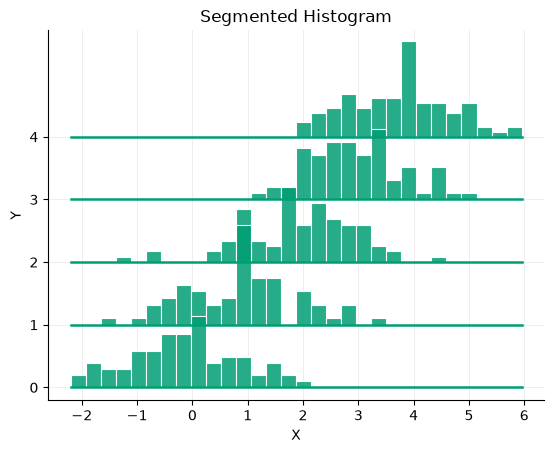

In [6]:
# Heavier fill and an explicit color (Okabe-Ito green)
ax = plt.gca()
make_segmented_hist(values, groups, ax, color="#009E73", alpha=0.85)
plt.show()

## 4. Sparse levels fall back to tick marks

A level with fewer than two distinct values would be a single full-height spike
under the shared density scale, dwarfing every real histogram. Rather than letting
one lonely observation distort the whole plot, that level keeps its baseline and
shows its observations as short tick marks (a tiny rug) — the same fallback as the
segmented density plot — and a note explains what happened and how to fix it. Here
level 9 has a single observation at 0.

Note: level(s) 9 have fewer than 2 distinct values, so their observations are drawn as tick marks on the baseline instead of a histogram. Simulating more draws will fill those levels in.


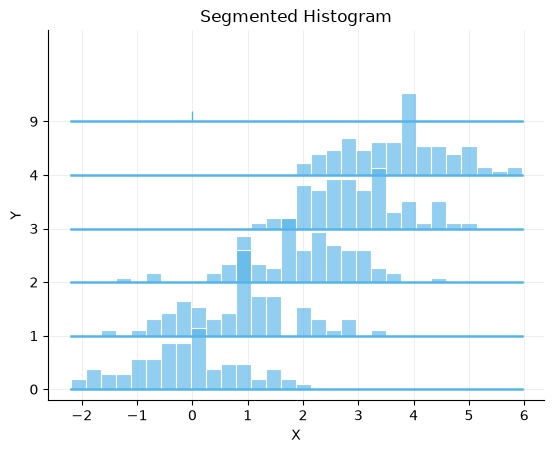

In [7]:
ax = plt.gca()
make_segmented_hist(
    np.append(values, 0.0),   # one extra observation ...
    np.append(groups, 9),     # ... at a level of its own
    ax,
)
plt.show()

## 5. Overlay behavior — mimicking two `.plot()` calls

No color arguments here either: with `color` omitted, each batch takes the next hue
from the active style sheet's cycle automatically. A second segmented histogram on
the same axes lands its rows on the same baselines (levels are matched by value),
comes out in the next Okabe-Ito hue, and a legend appears automatically in the top
right, auto-named "Variable 1", "Variable 2", ... A single batch gets no legend.

Each batch is binned on its own shared edges and scaled to its own tallest bar, so
overlays compare *shapes*, not absolute heights.

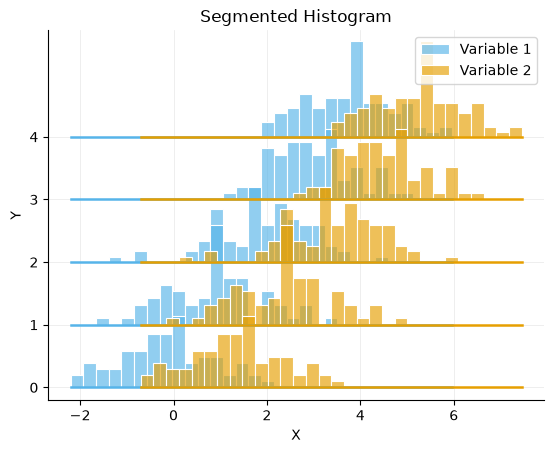

In [8]:
ax = plt.gca()
make_segmented_hist(values, groups, ax)        # sky blue, automatically
make_segmented_hist(values + 1.5, groups, ax)  # orange, automatically; legend appears
plt.show()

### Custom legend labels

`label=` overrides the automatic "Variable k" names.

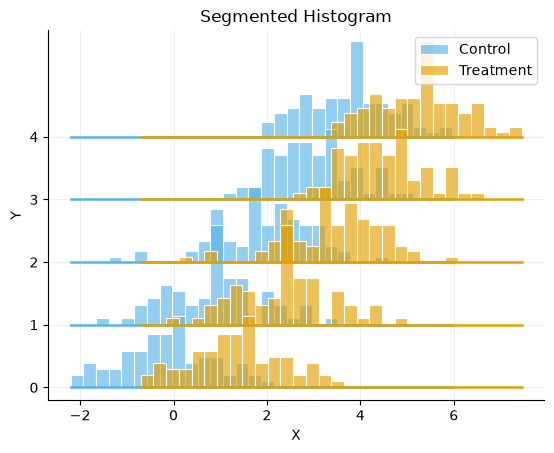

In [9]:
ax = plt.gca()
make_segmented_hist(values, groups, ax, label="Control")
make_segmented_hist(values + 1.5, groups, ax, label="Treatment")
plt.show()

## 6. With real symbulate simulation data

The same joint discrete × continuous pair the segmented density demo uses: `X`
counts successes (Binomial), `Y` is Normal with mean `X`, so the rows shift right as
the level climbs. This is the configuration where the lookup table's mixed-data
alternatives apply.

Simulation output arrives as one float array, so the discrete column is cast to int
here to steer the dtype-based detection — at integration, `classify_data` makes this
call instead.

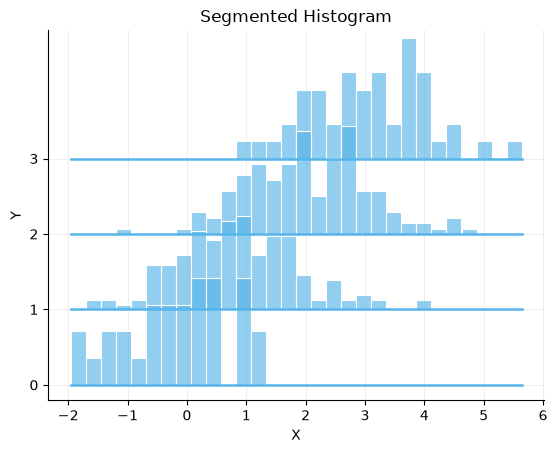

In [10]:
from symbulate import RV, Binomial, Normal

P = Binomial(3, 0.5) * Normal(0, 1)
X = RV(P, lambda outcome: outcome[0])               # discrete: 0, 1, 2, 3
Y = RV(P, lambda outcome: outcome[0] + outcome[1])  # continuous, mean = X
sims = (X & Y).sim(400)

arr = np.asarray(sims.results)
x_levels = arr[:, 0].astype(int)  # cast so the draft's dtype detection sees discrete
y_values = arr[:, 1]

ax = plt.gca()
make_segmented_hist(y_values, x_levels, ax)  # discrete on y: classic look
plt.show()

## 7. A process over time — one row per time point

The same discrete-time continuous-state view the segmented density demo shows, in
histogram form: standard Brownian motion has B(t) ~ Normal(0, √t), so the rows
should widen — and, under the shared height scale, flatten — as t grows.

(Each time point is simulated independently here, so the rows show the marginal
distribution at each time.)

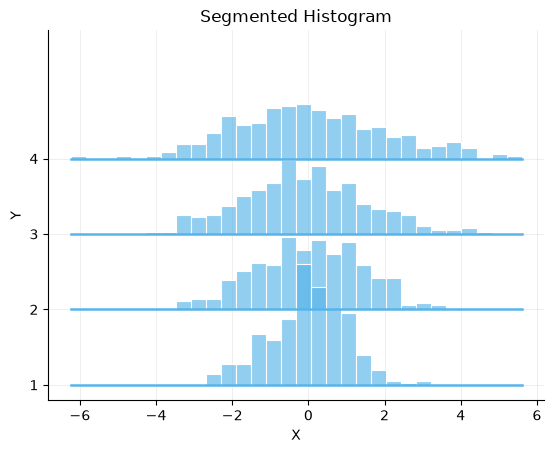

In [11]:
from symbulate import BrownianMotion

B = BrownianMotion()
times = [1, 2, 3, 4]
bm_values = np.concatenate([np.asarray(B[t].sim(300).results) for t in times])
bm_times = np.repeat(times, 300)  # int dtype -> auto-detected discrete

ax = plt.gca()
make_segmented_hist(bm_values, bm_times, ax)
plt.show()  # time runs up the y-axis; rows widen and flatten

## 8. Only for mixed data

A segmented histogram needs exactly one discrete and one continuous variable. Two
continuous variables (or two discrete) raise a student-friendly error pointing to
the right plot type — scatter for two continuous, tile or jittered scatter for two
discrete.

In [12]:
# Two continuous variables -> not a segmented histogram; raises a helpful error.
try:
    make_segmented_hist(values, rng.normal(0, 1, 400), plt.gca())
except ValueError as e:
    print(f"ValueError: {e}")

# Two discrete variables -> same, pointing at tile / jittered scatter.
try:
    make_segmented_hist(groups, groups, plt.gca())
except ValueError as e:
    print(f"ValueError: {e}")
plt.close("all")  # nothing meaningful was drawn; discard the empty figure

ValueError: A segmented histogram needs one discrete variable and one continuous variable, but both of yours look continuous. Try a scatter plot for two continuous variables.
ValueError: A segmented histogram needs one discrete variable and one continuous variable, but both of yours look discrete. Try a tile plot or a scatter plot with jitter for two discrete variables.


## Verification checklist

- [ ] One histogram row per discrete level, stacked along the discrete axis with a
  gentle overlap; lower rows drawn in front
- [ ] Bars line up in columns across rows (shared bin edges from the pooled values)
- [ ] Shared height scale — tallest bar ≈ 1.6 baseline spacings; other bars keep
  their true relative heights
- [ ] Bars styled like the 1D histogram (translucent fill, thin white edges); every
  level has a baseline in the ridge color spanning the shared bin range
- [ ] Section 2: orientation flips when x is the discrete variable (rightward bars,
  columns stacked horizontally), mirroring the other mixed-data plots
- [ ] `bins=` changes the shared bin grid; `normalize=False` shows raw counts
  (smaller groups get visibly shorter rows); `alpha=` changes only the fill
- [ ] With no `color` argument, the first batch is Okabe-Ito sky blue and a second
  call automatically advances to orange; explicit `color=` still overrides
- [ ] Section 4: a sparse level keeps its baseline, shows tick marks, and prints a
  note that says what happened and how to fix it (simulate more draws)
- [ ] Single batch has no legend; legend appears in the top right on the second
  overlaid batch, auto-named "Variable 1", "Variable 2", ...; `label=` overrides
- [ ] Works on real `.sim()` output (joint RV and BrownianMotion time points), not
  just numpy arrays
- [ ] Section 7: Brownian motion rows widen and flatten as t grows
- [ ] Two continuous or two discrete variables raise the friendly ValueError naming
  the right plot type
- [ ] Light reference grid behind the bars on both axes (drawn below, never over)
- [ ] Axis labels "X"/"Y", title "Segmented Histogram" (static — the 1D histogram's
  Density/Count title split is a team question for this plot type)